# Predecir con regresión lineal y evaluación del modelo

En este cuaderno vamos a construir un primer modelo de **regresión lineal** para predecir un valor numérico continuo a partir de distintas variables predictoras.

Retomaremos la lógica de trabajo que venimos usando en cuadernos anteriores: primero cargaremos y exploraremos el dataset, luego prepararemos las variables, dividiremos los datos en conjuntos de entrenamiento y prueba, entrenaremos un modelo con `Scikit-learn` y finalmente evaluaremos su desempeño con distintas métricas.

En particular, nos interesa comprender:

- qué significa predecir una variable numérica continua,
- cuándo tiene sentido usar regresión lineal,
- cómo se entrena este modelo en Python,
- y cómo interpretar métricas como **MAE**, **MSE**, **RMSE** y **R²**.

## Dataset utilizado

En este cuaderno volveremos a trabajar con el dataset **"Popular Video Games 1980-2023"**, publicado en Kaggle por el usuario **arnabchaki**.

Dataset [disponible en Kaggle](https://www.kaggle.com/datasets/arnabchaki/popular-video-games-1980-2023/data)

Ya lo hemos utilizado en un cuaderno anterior, por lo que no vamos a detenernos demasiado en su descripción general. En esta oportunidad, lo retomaremos con otro objetivo: en lugar de usarlo para clasificación, lo utilizaremos como base para construir un ejemplo de **regresión lineal**.

## ¿En qué consiste la regresión lineal?

La **regresión lineal** es un modelo de aprendizaje automático supervisado que se utiliza cuando queremos **predecir un valor numérico continuo** a partir de una o más variables predictoras.

La idea general del modelo es encontrar una relación matemática entre esas variables de entrada y la variable que queremos estimar.

Cuando trabajamos con una sola variable predictora, esa relación puede pensarse como una recta:

**y = a·x + b**

donde:

- **x** representa la variable predictora,
- **y** representa la variable objetivo,
- **a** indica cuánto cambia `y` cuando `x` aumenta una unidad,
- y **b** es el intercepto, es decir, el valor de `y` cuando `x = 0`.

Cuando trabajamos con varias variables predictoras, la expresión se amplía:

**y = a₁x₁ + a₂x₂ + ... + aₙxₙ + b**

En ese caso, ya no estamos describiendo una recta, sino una forma geométrica de mayor dimensión:

* con **una** variable predictora, el modelo se representa como una **recta**;
* con **dos** variables predictoras, pasa a ser un **plano**;
* con **tres** o más, hablamos de un **hiperplano**.

Sin embargo, seguimos hablando de regresión lineal porque la predicción se construye como una **combinación lineal** de las variables de entrada.

En este cuaderno, la variable objetivo será **`Rating`**. Es decir, vamos a entrenar un modelo que intente predecir la valoración de un videojuego a partir de otras características numéricas del dataset.

La regresión lineal es un buen punto de partida porque es un modelo **simple, rápido e interpretable**. Al mismo tiempo, tiene una limitación importante: como supone una relación lineal entre las variables, no siempre logra captar comportamientos más complejos. Por eso suele ser útil como primera aproximación, aunque no necesariamente como solución definitiva.

## Importación de librerías

Antes de comenzar a trabajar con los datos, necesitamos importar algunas librerías de Python que nos van a acompañar a lo largo de todo el cuaderno.

Vamos a usar:

- **pandas** para cargar y manipular el dataset,
- **numpy** para algunas operaciones numéricas,
- **matplotlib** para realizar gráficos,
- y herramientas de **Scikit-learn** para dividir los datos, entrenar el modelo de regresión lineal y evaluar sus resultados.

In [21]:
# ==========================================================
# IMPORTAMOS LAS LIBRERÍAS PRINCIPALES
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carga del dataset

Como ya vimos en cuadernos anteriores, el primer paso consiste en cargar el dataset con el que vamos a trabajar.

En este caso volveremos a usar el conjunto de datos **"Popular Video Games 1980-2023"**. No nos detendremos demasiado en esta etapa, ya que tanto la carga de datos como la exploración inicial y algunas tareas de preparación forman parte de un flujo de trabajo que ya conocemos.

Nuestro interés, en esta oportunidad, estará puesto principalmente en otra cuestión: cómo adaptar ese dataset para plantear un problema de **regresión**, entrenar un modelo y evaluar qué tan buenas son sus predicciones.

In [22]:
# ==========================================================
# CARGAMOS EL DATASET
# ==========================================================

# Si el archivo ya está disponible en una ruta local, lo usamos directamente.
# En caso contrario, lo descargamos desde Kaggle.

ruta_local = "/content/games.csv"

if os.path.exists(ruta_local):
    ruta_csv = ruta_local
else:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download("arnabchaki/popular-video-games-1980-2023")
    ruta_csv = os.path.join(ruta_dataset, "games.csv")

games = pd.read_csv(ruta_csv)

print("Dataset cargado correctamente.")
print("Dimensiones:", games.shape)

display(games.head())

Using Colab cache for faster access to the 'popular-video-games-1980-2023' dataset.
Dataset cargado correctamente.
Dimensiones: (1512, 14)


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


## Primer vistazo al dataset

Una vez cargados los datos, conviene hacer una revisión general de su estructura.

No se trata todavía de analizar en profundidad cada columna, sino de recuperar algunas preguntas básicas que ya venimos trabajando en otros cuadernos: cuántas filas y columnas tiene el dataset, qué variables incluye, qué tipos de datos aparecen y si, a primera vista, encontramos columnas que podrían servirnos para plantear un problema de regresión.

Esa revisión inicial nos interesa especialmente por una razón: necesitamos identificar una **variable numérica continua** que pueda funcionar como objetivo de predicción.

In [23]:
# ==========================================================
# EXPLORACIÓN INICIAL DE LA ESTRUCTURA DEL DATASET
# ==========================================================

print("Columnas del dataset:")
print(games.columns.tolist())

print("\nInformación general:")
games.info()

print("\nResumen estadístico de las variables numéricas:")
display(games.describe())

Columnas del dataset:
['Unnamed: 0', 'Title', 'Release Date', 'Team', 'Rating', 'Times Listed', 'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  B

,Unnamed: 0,Rating
count,1512.000000,1499.000000
mean,755.500000,3.719346
std,436.621117,0.532608
min,0.000000,0.700000
25%,377.750000,3.400000
50%,755.500000,3.800000
75%,1133.250000,4.100000
max,1511.000000,4.800000


## Elección de la variable objetivo

A partir de esta exploración inicial, podemos hacer una primera observación importante: la columna **`Rating`** ya aparece como una variable numérica, y además representa un valor continuo.

Por esa razón, la vamos a tomar como nuestra **variable objetivo**. Es decir, intentaremos construir un modelo que pueda **predecir la valoración de un videojuego** a partir de otras variables del dataset.

También vemos que varias columnas vinculadas con interacción o actividad de los usuarios, como `Times Listed`, `Number of Reviews`, `Plays`, `Playing`, `Backlogs` y `Wishlist`, todavía están almacenadas como texto. Aunque a simple vista parecen variables cuantitativas, antes de utilizarlas tendremos que revisar su formato y, si corresponde, transformarlas en variables numéricas.

Como estas tareas de inspección y limpieza ya forman parte de un flujo de trabajo conocido, avanzaremos de manera más directa hacia la preparación del dataset para el modelo de regresión.

## Preparación de variables numéricas

Antes de entrenar el modelo, necesitamos asegurarnos de que las variables que pensamos usar como predictoras estén en un formato adecuado.

Ya vimos en cuadernos anteriores que, en muchos datasets, algunas columnas numéricas aparecen almacenadas como texto. Eso ocurre aquí con variables como `Plays`, `Playing`, `Backlogs` o `Wishlist`, donde pueden aparecer valores como `"3.9K"` o `"17K"`.

Para poder utilizarlas en un modelo de regresión, primero las vamos a transformar en valores numéricos reales.

In [24]:
# ==========================================================
# CONVERTIMOS COLUMNAS CON FORMATO TIPO "K" A VALORES NUMÉRICOS
# ==========================================================

def convertir_k_a_numero(valor):
    """
    Convierte textos como '3.9K', '17K' o '230' a números.
    Si el valor es nulo, devuelve NaN.
    """
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().upper()

    if valor.endswith("K"):
        return float(valor[:-1]) * 1000
    else:
        return float(valor)

# Columnas a las que vamos a aplicar la conversión
columnas_numericas_texto = [
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

# Hacemos una copia para trabajar con seguridad
games_transformado = games.copy()

# Aplicamos la conversión
for columna in columnas_numericas_texto:
    games_transformado[columna] = games_transformado[columna].apply(convertir_k_a_numero)

# Verificamos el resultado
display(games_transformado[columnas_numericas_texto].head(10))
print(games_transformado[columnas_numericas_texto].dtypes)

,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0
1,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0
2,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0
3,3500.0,3500.0,28000.0,679.0,4900.0,1800.0
4,3000.0,3000.0,21000.0,2400.0,8300.0,2300.0
5,2300.0,2300.0,33000.0,1800.0,1100.0,230.0
6,1600.0,1600.0,7200.0,1100.0,4500.0,3800.0
7,2100.0,2100.0,9200.0,759.0,3400.0,3300.0
8,867.0,867.0,25000.0,470.0,776.0,126.0
9,2900.0,2900.0,18000.0,1100.0,6200.0,3600.0


Times Listed         float64
Number of Reviews    float64
Plays                float64
Playing              float64
Backlogs             float64
Wishlist             float64
dtype: object


## Selección de variables para el modelo

Después de la conversión, ya disponemos de varias columnas numéricas que podrían ayudarnos a predecir `Rating`.

En este ejemplo vamos a trabajar con un conjunto acotado de variables vinculadas con la interacción de los usuarios con cada juego, como la cantidad de reseñas, partidas registradas, usuarios jugando actualmente, juegos en backlog y cantidad de veces que el título fue agregado a listas o listas de deseo.

Antes de entrenar el modelo, nos conviene revisar si estas columnas tienen valores faltantes y construir un nuevo subconjunto de datos que incluya solamente la variable objetivo y las variables predictoras que vamos a utilizar.

In [25]:
# ==========================================================
# SELECCIONAMOS VARIABLES Y REVISAMOS VALORES FALTANTES
# ==========================================================

columnas_modelo = [
    "Rating",
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

games_modelo = games_transformado[columnas_modelo].copy()

print("Valores faltantes por columna:")
print(games_modelo.isnull().sum())

print("\nDimensiones antes de eliminar nulos:", games_modelo.shape)

games_modelo = games_modelo.dropna()

print("Dimensiones después de eliminar nulos:", games_modelo.shape)

display(games_modelo.head())

Valores faltantes por columna:
Rating               13
Times Listed          0
Number of Reviews     0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

Dimensiones antes de eliminar nulos: (1512, 7)
Dimensiones después de eliminar nulos: (1499, 7)


,Rating,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,4.5,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0
1,4.3,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0
2,4.4,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0
3,4.2,3500.0,3500.0,28000.0,679.0,4900.0,1800.0
4,4.4,3000.0,3000.0,21000.0,2400.0,8300.0,2300.0


## Dataset listo para el modelado

Después de la limpieza, nos quedamos con un subconjunto de datos sin valores faltantes en las variables que vamos a usar.

La única columna que presentaba valores nulos era `Rating`, nuestra variable objetivo. Como fueron pocos casos en relación con el total, en este ejemplo optamos por eliminarlos para trabajar con un dataset completo y consistente.

A partir de este punto, ya podemos pasar al armado del problema de regresión propiamente dicho:

- por un lado, definiremos las **variables predictoras**,
- por otro, la **variable objetivo**,
- y luego dividiremos los datos en conjuntos de entrenamiento y prueba.

Este paso ya nos resulta familiar de cuadernos anteriores. La diferencia, ahora, es que nuestro objetivo no será predecir una categoría, sino un **valor numérico continuo**.

In [26]:
# ==========================================================
# DEFINIMOS VARIABLES PREDICTORAS (X) Y VARIABLE OBJETIVO (y)
# ==========================================================

X = games_modelo.drop(columns="Rating")
y = games_modelo["Rating"]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())
display(y.head())

Variables predictoras:
['Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']

Dimensiones de X: (1499, 6)
Dimensiones de y: (1499,)


,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0
1,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0
2,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0
3,3500.0,3500.0,28000.0,679.0,4900.0,1800.0
4,3000.0,3000.0,21000.0,2400.0,8300.0,2300.0


,Rating
0,4.5
1,4.3
2,4.4
3,4.2
4,4.4


## Una primera mirada a la relación entre variables

Antes de entrenar el modelo, puede ser útil observar de manera simple cómo se relaciona alguna variable predictora con `Rating`.

Esto no reemplaza el modelado ni demuestra por sí solo que la relación sea lineal, pero sí nos permite obtener una primera intuición visual. Recordemos que la regresión lineal suele ser una buena primera opción cuando existe una tendencia general entre las variables, aunque no sea perfecta.

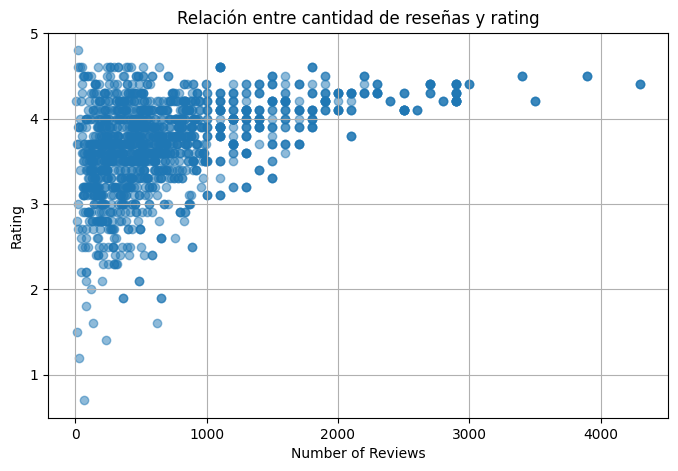

In [27]:
# ==========================================================
# VISUALIZACIÓN SIMPLE DE UNA RELACIÓN POSIBLE
# ==========================================================

plt.figure(figsize=(8, 5))
plt.scatter(games_modelo["Number of Reviews"], games_modelo["Rating"], alpha=0.5)
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Relación entre cantidad de reseñas y rating")
plt.grid(True)
plt.show()

### Lectura breve del gráfico

Este gráfico ofrece una primera mirada exploratoria sobre la relación entre la cantidad de reseñas y `Rating`.

Se observa una tendencia general positiva: a medida que aumenta la cantidad de reseñas, los valores de `Rating` tienden, en promedio, a ubicarse en zonas algo más altas. Sin embargo, la dispersión sigue siendo considerable, por lo que esta relación no es suficiente, por sí sola, para explicar el comportamiento de la variable objetivo.

Por eso, esta visualización no busca sacar conclusiones definitivas, sino simplemente aportar una intuición inicial antes del entrenamiento del modelo.

## División en entrenamiento y prueba

Como hemos hecho en otras oportunidades, vamos a separar los datos en dos conjuntos:

- un conjunto de **entrenamiento**, que usaremos para ajustar el modelo,
- y un conjunto de **prueba**, que reservaremos para evaluar cómo funciona con datos que no vio durante el entrenamiento.

La diferencia, en esta oportunidad, es que no estamos trabajando con un problema de clasificación, sino con uno de **regresión**. Es decir, el modelo no intentará asignar una clase, sino estimar un valor numérico.

In [28]:
# ==========================================================
# DIVIDIMOS LOS DATOS EN ENTRENAMIENTO Y PRUEBA
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Dimensiones de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDimensiones de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Dimensiones de entrenamiento:
X_train: (1199, 6)
y_train: (1199,)

Dimensiones de prueba:
X_test: (300, 6)
y_test: (300,)


## Entrenamiento del modelo de regresión lineal

Una vez definidos los conjuntos de entrenamiento y prueba, ya estamos en condiciones de construir nuestro primer modelo de **regresión lineal**.

La regresión lineal busca ajustar una relación matemática entre las variables predictoras y la variable objetivo. En términos sencillos, intenta encontrar la combinación de coeficientes que mejor permita estimar el valor de `Rating` a partir de las demás variables.

En `Scikit-learn`, este proceso se realiza con la clase `LinearRegression`. Primero creamos el modelo, luego lo entrenamos con el método `.fit()` usando los datos de entrenamiento.

Más adelante vamos a usar ese modelo ya entrenado para generar predicciones sobre el conjunto de prueba y evaluar qué tan buenas son.

In [29]:
# ==========================================================
# ENTRENAMOS EL MODELO DE REGRESIÓN LINEAL
# ==========================================================

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

print("\nIntercepto:")
print(modelo.intercept_)

print("\nCoeficientes:")
for variable, coeficiente in zip(X.columns, modelo.coef_):
    print(f"{variable}: {coeficiente}")

Modelo entrenado correctamente.

Intercepto:
3.442228105245843

Coeficientes:
Times Listed: 0.00026441932661894695
Number of Reviews: 0.0002644193266189474
Plays: -3.3952963955637523e-05
Playing: -0.0001773206715837426
Backlogs: 3.929644958577281e-05
Wishlist: 7.793982483009752e-05


## Primer vistazo a los parámetros del modelo

Una vez entrenado el modelo, `Scikit-learn` nos permite consultar dos elementos importantes:

- el **intercepto**, que representa el valor base desde el cual parte la predicción,
- y los **coeficientes**, que indican cómo influye cada variable predictora sobre el valor estimado de `Rating`.

En una regresión lineal, cada coeficiente nos dice cuánto cambia la predicción cuando la variable correspondiente aumenta una unidad, manteniendo constantes las demás.

De todos modos, en este punto conviene ser prudentes con la interpretación. Como las variables están en escalas muy distintas y además algunas pueden estar relacionadas entre sí, no siempre tiene sentido extraer conclusiones fuertes solo mirando estos coeficientes. Por ahora, nos alcanza con entender que el modelo ya aprendió una regla matemática para combinar las variables de entrada y producir una predicción numérica.

El siguiente paso será usar este modelo para generar predicciones sobre el conjunto de prueba y comparar esos valores estimados con los valores reales.

In [30]:
# ==========================================================
# GENERAMOS PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA
# ==========================================================

y_pred = modelo.predict(X_test)

print("Primeras 10 predicciones del modelo:")
print(y_pred[:10])

print("\nPrimeros 10 valores reales:")
print(y_test.iloc[:10].values)

Primeras 10 predicciones del modelo:
[3.64510719 3.43497977 3.87160457 4.15115643 3.95179843 3.69625763
 3.62180851 3.45189495 3.67104361 3.51829581]

Primeros 10 valores reales:
[4.1 3.2 4.1 4.1 3.8 3.5 2.8 1.2 4.1 3.2]


## Predicciones y necesidad de evaluar el modelo

Al aplicar el modelo sobre el conjunto de prueba, obtenemos una serie de valores predichos para `Rating`.

Como puede verse, esas predicciones no coinciden exactamente con los valores reales, y eso es completamente normal. En los problemas de regresión, el objetivo no es “acertar” una clase, sino **aproximar lo mejor posible un valor numérico**.

Por eso, para saber si el modelo funciona bien o no, no alcanza con mirar unos pocos ejemplos. Necesitamos usar métricas que nos permitan resumir, de manera más objetiva, qué tan lejos estuvieron las predicciones respecto de los valores reales.

Vamos a trabajar con cuatro métricas muy habituales:

- **MAE**: error absoluto medio,
- **MSE**: error cuadrático medio,
- **RMSE**: raíz del error cuadrático medio,
- **R²**: coeficiente de determinación.


A diferencia de los problemas de clasificación, donde solemos hablar de aciertos y errores en categorías, en regresión trabajamos con **distancias entre valores reales y valores predichos**.

Por eso vamos a analizar el modelo usando varias métricas. Cada una aporta una mirada distinta sobre el error de predicción, y juntas nos permiten construir una evaluación más completa.

## MAE: error absoluto medio

El **MAE** (`Mean Absolute Error`) es una de las métricas más sencillas e intuitivas para evaluar un modelo de regresión. Su función es medir, en promedio, **cuánto se alejan las predicciones del modelo respecto de los valores reales**.

> Para calcularlo, se toma la diferencia entre cada valor predicho y cada valor real, se considera su **valor absoluto** y luego se obtiene el promedio de todas esas diferencias.

La idea de usar valor absoluto es importante: si no lo hiciéramos, los errores positivos y negativos podrían compensarse entre sí. Por ejemplo, un error de `+0.4` y otro de `-0.4` sumarían cero, y eso daría una impresión engañosa del desempeño del modelo. En cambio, al tomar valores absolutos, todos los errores cuentan por su magnitud, sin importar la dirección.

Una gran ventaja del MAE es que se expresa en la **misma unidad que la variable objetivo**. En este caso, como estamos intentando predecir `Rating`, el resultado del MAE nos indicará cuántos puntos de `Rating` se equivoca el modelo, en promedio.

Por eso, el MAE suele ser una muy buena primera métrica para interpretar el rendimiento de un modelo: ofrece una medida clara, directa y fácil de comunicar del error medio de predicción.

In [31]:
# ==========================================================
# CALCULAMOS EL MAE
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

MAE: 0.3410


### Interpretación del MAE

El resultado obtenido fue:

**MAE = 0.3410**

Esto significa que, en promedio, las predicciones del modelo se desvían aproximadamente **0.34 puntos** respecto del valor real de `Rating`.

Como la escala de `Rating` en este dataset se mueve aproximadamente entre 0.7 y 4.8, este error medio no parece desmesurado. Dicho de otro modo, el modelo no predice de manera exacta, pero tampoco se aleja demasiado, en promedio, de las valoraciones reales.

Una de las fortalezas del MAE es justamente esa: nos ofrece una medida clara y fácil de interpretar del error medio del modelo.

## MSE: error cuadrático medio

El **MSE** (`Mean Squared Error`) también mide la diferencia entre los valores predichos por el modelo y los valores reales, pero lo hace de una manera distinta al MAE: antes de promediar los errores, los **eleva al cuadrado**.

Ese detalle cambia bastante la interpretación de la métrica. Al elevar cada error al cuadrado, los errores grandes aumentan mucho más que los pequeños. Por ejemplo, un error de `2` no pesa simplemente el doble que un error de `1`, sino cuatro veces más. Por eso, el MSE penaliza con mucha fuerza las predicciones que se alejan demasiado de la realidad.

Esto vuelve al MSE especialmente útil cuando nos interesa detectar si el modelo está cometiendo errores importantes en algunos casos, aunque el promedio general no parezca tan malo. En otras palabras, es una métrica que “castiga” con mayor severidad los desvíos grandes.

Su principal desventaja es que pierde parte de la interpretación directa que sí tiene el MAE. Como los errores están al cuadrado, el resultado ya no queda expresado en la misma unidad que la variable objetivo. En este caso, no se leería directamente en “puntos de `Rating`”, lo que hace que su significado sea un poco menos intuitivo.

Aun así, el MSE es una métrica muy valiosa porque complementa al MAE: mientras el MAE nos da una idea clara del error medio, el MSE nos ayuda a ver si dentro de ese comportamiento general hay errores grandes que conviene mirar con más atención.

In [32]:
# ==========================================================
# CALCULAMOS EL MSE
# ==========================================================

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

MSE: 0.2156


### Interpretación del MSE

El resultado obtenido fue:

**MSE = 0.2156**

Este valor resume el error del modelo dando un peso mayor a las predicciones que se alejan mucho de los valores reales.

A diferencia del MAE, el MSE no se interpreta tan fácilmente en términos directos, porque trabaja con errores elevados al cuadrado. Sin embargo, sí nos resulta útil para detectar si el modelo está cometiendo errores grandes que conviene penalizar con más fuerza.

En otras palabras, el MSE complementa al MAE: no nos dice solo cuánto se equivoca el modelo en promedio, sino también cuánto impactan los errores más importantes dentro de ese promedio.

## RMSE: raíz del error cuadrático medio

El **RMSE** (`Root Mean Squared Error`) se obtiene calculando la **raíz cuadrada del MSE**.

A primera vista puede parecer un simple ajuste matemático, pero en realidad cumple una función importante. Recordemos que el MSE eleva los errores al cuadrado, lo que permite penalizar con más fuerza los desvíos grandes, pero también hace que el resultado quede en una escala menos intuitiva. Al aplicar la raíz cuadrada, el RMSE recupera la **misma unidad que la variable objetivo**.

En este caso, eso significa que el RMSE vuelve a expresarse en puntos de `Rating`, lo que facilita mucho su interpretación. Por eso, suele resultar más fácil de leer que el MSE.

Al mismo tiempo, el RMSE conserva parte de la sensibilidad a los errores grandes que caracteriza al MSE. Es decir, no se comporta exactamente igual que el MAE: sigue dando más peso a las predicciones que se alejan mucho de los valores reales, aunque lo hace de una manera más interpretable.

Por eso, podemos pensar al RMSE como una métrica intermedia entre MAE y MSE: mantiene la lógica de penalizar errores grandes, pero con una lectura más cercana a la escala real del problema.

In [33]:
# ==========================================================
# CALCULAMOS EL RMSE
# ==========================================================

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.4643


### Interpretación del RMSE

El resultado obtenido fue:

**RMSE = 0.4643**

Esto significa que, si queremos expresar el error del modelo en una escala comparable con `Rating`, la desviación típica de las predicciones ronda los **0.46 puntos**.

A diferencia del MAE, el RMSE penaliza más los errores grandes. Por eso, si su valor aumenta bastante respecto del MAE, puede ser una señal de que existen algunas predicciones particularmente alejadas de los valores reales.

En este caso, el RMSE es algo mayor que el MAE, lo cual es esperable. Esto sugiere que, además del error medio general, hay algunas predicciones con desvíos más importantes.

## R²: coeficiente de determinación

El **R²**, también llamado **coeficiente de determinación**, mide qué proporción de la variabilidad de la variable objetivo puede ser explicada por el modelo.

> A diferencia de métricas como **MAE**, **MSE** o **RMSE**, el R² no se centra directamente en cuánto se equivoca el modelo en cada predicción, sino en **qué tan bien logra capturar la relación general entre las variables predictoras y la variable objetivo**.

Dicho de otra manera: el R² intenta responder cuánto del comportamiento observado en la variable que queremos predecir queda efectivamente representado por el modelo.

En general:

- un valor cercano a **1** indica que el modelo explica muy bien los datos,
- un valor cercano a **0** indica que explica poco,
- y un valor **negativo** puede señalar que el modelo está funcionando peor que una predicción muy simple basada únicamente en el promedio.

Por ejemplo, si obtenemos un **R² = 0.70**, podemos decir que el modelo explica aproximadamente el **70% de la variabilidad** observada en la variable objetivo. Eso no significa que “acierte un 70%”, sino algo distinto: que logra representar bastante bien cómo varían los datos.

Esta aclaración es importante, porque el R² no debe interpretarse como una tasa de aciertos. Es una medida del **poder explicativo** del modelo, no una cuenta de predicciones correctas o incorrectas.

Por eso, el R² resulta muy útil para complementar las otras métricas. Mientras MAE, MSE y RMSE nos ayudan a entender el tamaño del error, el R² nos aporta una mirada más global sobre cuánto logra explicar el modelo del fenómeno que estamos analizando.

In [34]:
# ==========================================================
# CALCULAMOS EL COEFICIENTE DE DETERMINACIÓN R²
# ==========================================================

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.2375


### Interpretación de R²

El resultado obtenido fue:

**R² = 0.2375**

Esto significa que el modelo logra explicar aproximadamente un **23.75% de la variabilidad** observada en `Rating`.

Dicho de otro modo, las variables que usamos aportan cierta información para predecir la valoración de un videojuego, pero están lejos de explicar completamente su comportamiento. Esto no invalida el modelo, pero sí sugiere que su capacidad predictiva es moderada.

Este punto es importante: un modelo puede tener errores medios razonables y, al mismo tiempo, un valor de R² relativamente bajo. Eso ocurre porque cada métrica mira el desempeño desde una perspectiva diferente.

En nuestro caso, el modelo parece captar parcialmente la relación entre las variables, pero todavía deja una parte considerable de la variación de `Rating` sin explicar.

## Lectura conjunta de las métricas

Si reunimos los resultados obtenidos, podemos hacer una evaluación más completa del modelo:

- el **MAE** nos mostró que el error medio ronda los **0.34 puntos** de `Rating`,
- el **RMSE** indicó un error algo mayor, de alrededor de **0.46 puntos**, lo que sugiere la presencia de algunas predicciones más alejadas,
- el **MSE** reforzó esa idea al penalizar con más fuerza los errores grandes,
- y el **R²** mostró que el modelo solo explica una parte limitada de la variabilidad total de la variable objetivo.

En conjunto, estas métricas sugieren que la regresión lineal construida funciona como un primer modelo razonable, pero todavía bastante simple. Puede ofrecer estimaciones útiles como punto de partida, aunque no captura de manera especialmente fuerte la complejidad del problema.

Esto también es valioso desde el punto de vista del análisis: no se trata solo de obtener un resultado, sino de aprender a leerlo con criterio.

## Resumen comparativo de métricas

Para cerrar esta parte, conviene reunir en una sola tabla qué aporta cada métrica al análisis del modelo.

In [35]:
# ==========================================================
# TABLA RESUMEN DE MÉTRICAS
# ==========================================================

resumen_metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor obtenido": [mae, mse, rmse, r2],
    "Lectura breve": [
        "Error medio en la escala original",
        "Penaliza más los errores grandes",
        "Error en escala original con sensibilidad a errores grandes",
        "Proporción de variabilidad explicada por el modelo"
    ]
})


display(resumen_metricas)

,Métrica,Valor obtenido,Lectura breve
0,MAE,0.341019,Error medio en la escala original
1,MSE,0.215577,Penaliza más los errores grandes
2,RMSE,0.464302,Error en escala original con sensibilidad a er...
3,R²,0.237484,Proporción de variabilidad explicada por el mo...


## Visualización de predicciones reales y estimadas

Además de las métricas numéricas, una visualización simple puede ayudarnos a entender mejor cómo se comporta el modelo.

En el siguiente gráfico compararemos los valores reales de `Rating` con los valores predichos. Si el modelo funcionara de manera perfecta, todos los puntos quedarían alineados sobre una misma diagonal. Cuanto más cerca estén de esa línea ideal, mejor será el ajuste.

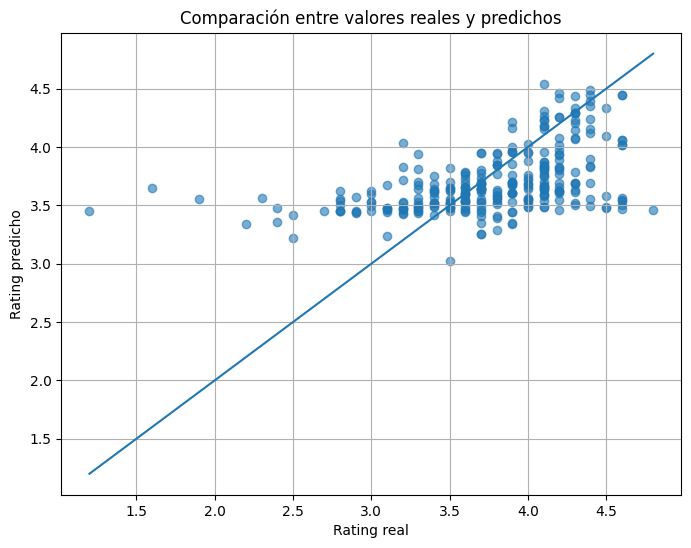

In [36]:
# ==========================================================
# GRÁFICO DE VALORES REALES VS VALORES PREDICHOS
# ==========================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Rating real")
plt.ylabel("Rating predicho")
plt.title("Comparación entre valores reales y predichos")
plt.grid(True)
plt.show()

### Interpretación del gráfico

El gráfico permite ver que el modelo sigue, en términos generales, la tendencia de los datos, pero también muestra una limitación importante: muchas predicciones se concentran en una franja relativamente estrecha de valores.

Esto sugiere que el modelo tiende a aproximarse a valores "intermedios" de `Rating` y le cuesta más representar correctamente los casos extremos, en especial los ratings reales más bajos.

Una posible explicación es que esos valores bajos estén menos representados en el dataset. Si hay pocos ejemplos de ese tipo durante el entrenamiento, el modelo dispone de menos información para aprender ese comportamiento y tiende a ajustar mejor la zona donde se concentra la mayor parte de los datos.

También influye el hecho de que estamos usando una **regresión lineal**, es decir, un modelo relativamente simple. Como primer aproximación resulta útil, pero no siempre logra capturar toda la complejidad del problema.

## Distribución de la variable objetivo

Para fundamentar esta idea con evidencia concreta, el siguiente paso lógico es hacer una visualización de la distribución de Rating, por ejemplo con un histograma:

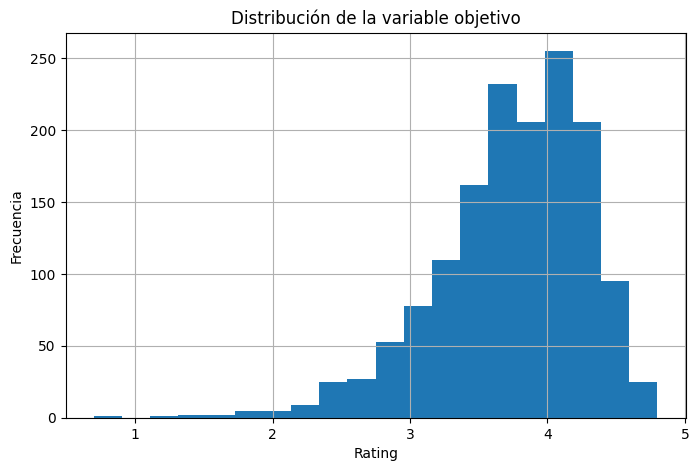

In [37]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

plt.figure(figsize=(8, 5))
plt.hist(y, bins=20)
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.grid(True)
plt.show()

### Análisis del histograma

El histograma muestra que la variable `Rating` no está distribuida de manera uniforme. La mayor parte de los casos se concentra en valores medios y altos, especialmente entre aproximadamente **3.3 y 4.4**, mientras que los ratings bajos aparecen con mucha menor frecuencia.

Esto es importante para interpretar el comportamiento del modelo. Si durante el entrenamiento hay pocos ejemplos con valores bajos de `Rating`, la regresión lineal tendrá menos información para aprender ese patrón y tenderá a predecir valores más cercanos a la zona donde se concentra la mayor parte de los datos.

En este caso, la distribución observada ayuda a explicar por qué el modelo se comporta peor cuando el valor real de `Rating` es especialmente bajo.

## Cierre

La regresión lineal es un modelo muy valioso como punto de partida en problemas donde queremos predecir una **variable numérica continua**. Entre sus principales ventajas se encuentran su **simplicidad**, su **rapidez de entrenamiento** y su **facilidad de interpretación**. Esto la convierte en una herramienta especialmente útil cuando buscamos construir una primera aproximación al problema, obtener una referencia inicial o comprender de qué manera ciertas variables se relacionan con el valor que queremos estimar.

Sin embargo, también tiene limitaciones. Al tratarse de un modelo lineal, no siempre logra captar relaciones más complejas entre los datos. Además, su desempeño puede verse afectado por la distribución de la variable objetivo, por la presencia de pocos casos en ciertos rangos de valores o por variables que no alcanzan a explicar suficientemente el fenómeno que estamos analizando. Por eso, un modelo de regresión lineal puede ser útil sin ser necesariamente suficiente.

Es por esto que las métricas de evaluación cumplen un papel fundamental. Medidas como **MAE**, **MSE**, **RMSE** y **R²** nos permiten ir más allá de una impresión superficial y analizar el comportamiento del modelo con criterios más precisos. Cada una aporta una mirada distinta: algunas ponen el foco en el error medio, otras penalizan con mayor fuerza los errores grandes, y otras muestran cuánto logra explicar el modelo de la variabilidad de los datos.

Trabajar con regresión lineal no consiste solamente en entrenar un modelo y obtener predicciones, sino también en **interpretar sus alcances y reconocer sus límites**.

*Esa lectura crítica es una parte central del trabajo con datos y será cada vez más importante a medida que avancemos hacia modelos más complejos.*

# Apéndice 1: Correlación entre variables numéricas

Antes de entrenar el modelo, podemos hacer una exploración adicional: observar la correlación entre las variables numéricas del dataset.

La correlación no determina por sí sola qué variables debemos usar, pero sí puede ofrecernos una primera pista sobre dos cuestiones importantes:

- qué variables parecen estar más relacionadas con `Rating`,
- y cuáles podrían estar muy relacionadas entre sí.

Como estamos trabajando con un modelo de regresión lineal, esta mirada puede resultar especialmente útil, ya que nos ayuda a detectar relaciones lineales de manera preliminar.

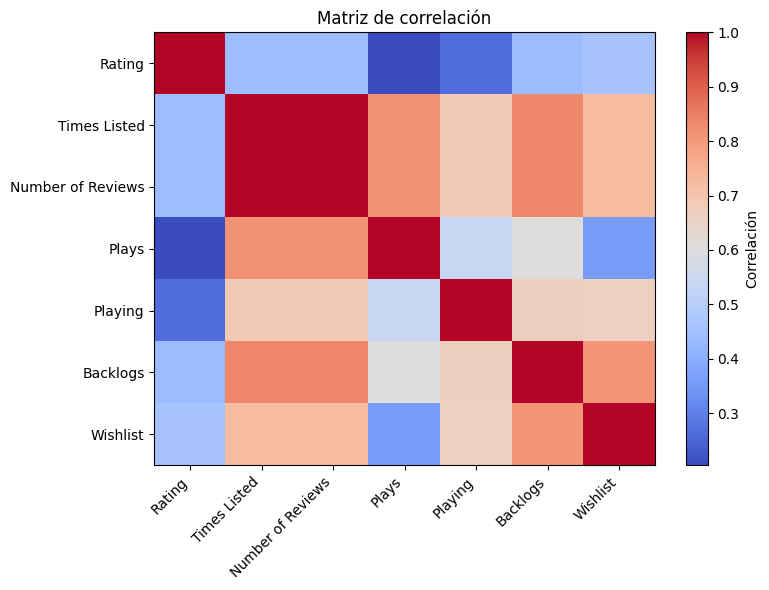

In [38]:
# ==========================================================
# MATRIZ DE CORRELACIÓN
# ==========================================================

matriz_corr = games_modelo.corr()

# display(matriz_corr)

plt.figure(figsize=(8, 6))
plt.imshow(matriz_corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

La matriz de correlación permite identificar qué variables presentan una relación lineal más fuerte con `Rating` y cuáles están muy relacionadas entre sí.

Esto no define automáticamente qué columnas deben incluirse en el modelo, pero sí aporta una orientación útil. En particular, si dos variables predictoras están fuertemente correlacionadas entre sí, puede ocurrir que aporten información parecida y que la interpretación de sus coeficientes dentro del modelo requiera más cautela.

Lo que muestra la matriz (en este ejemplo y con esas variables) es que `Rating` tiene una correlación positiva moderada con varias de las variables predictoras, como `Times Listed`, `Number of Reviews`, `Backlogs y Wishlist`. Eso es una buena señal, porque sugiere que existe cierta relación lineal aprovechable por una regresión lineal.

Pero también se ve que esas correlaciones no son muy altas. Están lejos de valores cercanos a 0.8 o 0.9 con `Rating`, que darían una señal mucho más contundente. Entonces, el gráfico sugiere que el modelo puede capturar parte del comportamiento de `Rating`, pero difícilmente lo explique de manera muy precisa.

Además, hay otro detalle importante: varias predictoras están muy correlacionadas entre sí. Por ejemplo, `Times Listed` y `Number of Reviews` parecen casi idénticas, y también hay relaciones fuertes entre otras variables de interacción.

> Esta exploración sugiere que `Rating` puede ser predicha con cierto grado de éxito, pero probablemente de manera limitada, algo que pudo confirmarse con las métricas de evaluación del modelo.